In [196]:
import pandas as pd
from pathlib import Path
from typing import List
import numpy as np
from tqdm import tqdm
import ast
from sentence_transformers import SentenceTransformer

MODELS = [
    "canary-finetune_spec-aug_speed-perturbations",
    "parakeet-finetune_spec-aug",
    "parakeet-finetune_SA_ll",
    "parakeet-finetune_SA_ll_SA",
    "parakeet-finetune_SA_ll_PS",
    "parakeet-finetune_SA_ll_SP",
    "parakeet-finetune_SA_ll_SA_PS",
    "parakeet-finetune_SA_ll_SA_SP",
    "parakeet-finetune_SA_ll_PS_SP",
    "parakeet-finetune_SA_ll_SA_PS_SP",
]

DATASETS = [
    "coral-v2",
    "fleurs",
    "lillelyd"
]

SUBSETS = {
    "coral-v2": "read_aloud",
    "fleurs": "da_dk",
    "lillelyd": "full",
}

CV_FOLDS = {
    "cv-1",
    "cv-2",
    "cv-3",
    "cv-4",
}

SPLITS = {
    "coral-v2": "test",
    "fleurs": "test",
    "lillelyd": "test",
}

def provide_combinations():
    combinations = []
    for m in MODELS:
        for d in DATASETS:
            if "ll" in m:
                for f in CV_FOLDS:
                    combinations.append(
                        {
                            "model": m,
                            "dataset_name": d,
                            "dataset_subset": SUBSETS[d],
                            "dataset_split": SPLITS[d],
                            "cv_fold": f,
                        }
                    )
            else:
                if d == "lillelyd":
                    for f in CV_FOLDS:
                        combinations.append(
                            {
                                "model": m,
                                "dataset_name": d,
                                "dataset_subset": SUBSETS[d],
                                "dataset_split": SPLITS[d],
                                "cv_fold": f,
                            }
                        )
                else:
                    combinations.append(
                        {
                            "model": m,
                            "dataset_name": d,
                            "dataset_subset": SUBSETS[d],
                            "dataset_split": SPLITS[d],
                            "cv_fold": None,
                        }
                    )
    return combinations

EVALUATION_COMBINATIONS = provide_combinations()


def to_dict_safe(x):
    if isinstance(x, dict):
        return x
    if pd.isna(x):
        return {}
    return ast.literal_eval(x if isinstance(x, str) else str(x))


def load_parquet(path: Path) -> pd.DataFrame:
    return pd.read_parquet(path, engine="pyarrow")


def get_path_to_latest_detailed_results_parquet(
    eval_combination: dict, base="experiments/evaluate_model"
) -> Path:
    """
    Returns the path to the latest detailed_results.parquet for the given eval combination.
    eval_combination: str
        A string of the form "{model}_{dataset}_{subset}_{split}"
    base: str
        The base directory where evaluation results are stored.
    """
    if eval_combination["cv_fold"] is None:
        root = (
            Path(base)
            / f"{eval_combination['model']}_{eval_combination['dataset_name']}_{eval_combination['dataset_subset']}_{eval_combination['dataset_split']}"
        )
    else:
        root = (
            Path(base)
            / f"{eval_combination['model']}_{eval_combination['cv_fold']}_{eval_combination['dataset_name']}_{eval_combination['dataset_subset']}_{eval_combination['dataset_split']}"
        )

    # find every detailed_results.parquet under root, ignore .hydra
    files = [p for p in root.rglob("detailed_results.parquet") if ".hydra" not in p.parts]
    if not files:
        raise FileNotFoundError(f"No detailed_results.parquet under {root}")

    newest = max(files, key=lambda p: p.stat().st_mtime)
    return newest

def _semantic_distance(label, prediction):
    return 1 - np.dot(label, prediction) / (np.linalg.norm(label) * np.linalg.norm(prediction))

def compute_sentence_embeddings(df: pd.DataFrame, st_model) -> pd.DataFrame:
    """Compute sentence embeddings for the predictions and labels in the DataFrame.

    Args:
        df:
            DataFrame with columns 'prediction' and 'label'.
        model_name:
            The name of the model to use for computing embeddings.

    Returns:
        DataFrame with additional columns 'prediction_embedding' and 'label_embedding'.
    """

    #logger.info(f"Loading sentence transformer model: {model_name}")
    model = st_model

    predictions = df["prediction"].tolist()
    labels = df["label"].tolist()

    #logger.info("Computing embeddings for predictions...")
    pred_embeddings = model.encode(predictions, normalize_embeddings=True, batch_size=256)

    #logger.info("Computing embeddings for labels...")
    label_embeddings = model.encode(labels, normalize_embeddings=True, batch_size=256)

    df["prediction_embedding"] = list(pred_embeddings)
    df["label_embedding"] = list(label_embeddings)

    #logger.info("Embeddings computed.")

    # finally, we need the semantic distance between prediction_embedding and label_embedding
    df["semantic_distance"] = df.apply(
        lambda x: _semantic_distance(x["label_embedding"], x["prediction_embedding"]), axis=1
    )
    return df


def load_latest_detailed_results_parsed(eval_combination: dict, base="experiments/evaluate_model", st_model=None) -> pd.DataFrame:
    """
    Returns (df, parquet_path)

    df columns: id, prediction, label, clip_length, CER, WER
    """
    try:
        newest = get_path_to_latest_detailed_results_parquet(eval_combination, base)
    except FileNotFoundError:
        return None

    # read with pyarrow to avoid partial row group reads
    df = pd.read_parquet(newest, engine="pyarrow")

    m = df["metrics"].apply(to_dict_safe)
    metrics_df = pd.json_normalize(m)

    # attach CER and WER, drop original metrics
    df = pd.concat([df.drop(columns=["metrics"]), metrics_df], axis=1).rename(
        columns={"cer": "CER", "wer": "WER"}
    )

    # add model, dataset_name, dataset_subset, dataset_split columns
    df["model"] = eval_combination["model"]
    df["dataset_name"] = eval_combination["dataset_name"]
    df["dataset_subset"] = eval_combination["dataset_subset"]
    df["dataset_split"] = eval_combination["dataset_split"]
    df["cv_fold"] = eval_combination["cv_fold"]

    # attach embeddings and semantic distance
    df = compute_sentence_embeddings(df, st_model=st_model)

    # check for lillelyd
    if eval_combination["dataset_name"] == "lillelyd":
        # for lillelyd, we split the id on "/" and take the two last parts and join them with "/"
        df["id"] = df["id"].apply(lambda x: "/".join(Path(x).parts[-2:]))
        pitch_data = pd.read_parquet("../reports/metrics/lillelyd-summary.parquet")
        # drop unneeded columns
        columns_to_drop = [
            "id_recording",
            "dataset_name",
            "clip_length"
        ]
        pitch_data = pitch_data.drop(columns=columns_to_drop)
        # rename audio_filepath to id in pitch_data
        pitch_data = pitch_data.rename(columns={"audio_filepath": "id"})
        df = df.merge(pitch_data, on="id", how="left")

    # For FLEUERS, the 'id' column is not actuallys id's but rather utterance indices.
    # Therefore, we remove the 'id' column to avoid confusion.
    if eval_combination["dataset_name"] == "fleurs":
        df = df.drop(columns=["id"])

        # next, we replace it with a new 'id' column that is simply a range from 1 to len(df)
        ids = [f"rec_{idx}" for idx in range(1, len(df) + 1)]
        df["id"] = ids

    if eval_combination["dataset_name"] == "coral-v2":
        pitch_data = pd.read_parquet("../reports/metrics/coral-v2-summary.parquet")
        # drop dataset_name column and clip_length column
        pitch_data = pitch_data.drop(columns=["dataset_name", "clip_length"])
        # rename id_recording to id in pitch_data
        pitch_data = pitch_data.rename(columns={"id_recording": "id"})
        df = df.merge(pitch_data, on="id", how="left")
        
    elif eval_combination["dataset_name"] == "fleurs":
        pitch_data = pd.read_parquet("../reports/metrics/fleurs-summary.parquet")
        # drop unneeded columns
        colums_to_drop = [
            "id",
            "gender",
            "dataset_name",
            "clip_length",
            "path",
            "num_samples",
            "transcription",
            "raw_transcription",
            "language",
            "lang_group_id",
            "lang_id",
        ]
        pitch_data = pitch_data.drop(columns=colums_to_drop)
        # rename id_recording to id in pitch_data
        pitch_data = pitch_data.rename(columns={"id_recording": "id"})

        df = df.merge(pitch_data, on="id", how="left")

    return df


def combine_all_detailed_results_lillelyd(base="../experiments/evaluate_model") -> pd.DataFrame:
    temp_dfs = []
    final_dfs = []

    # 1. Flatten the combinations first for a single, clean progress bar
    combinations = provide_combinations()

    # 2. Initialize the embedding model ONCE outside the loop
    print("Initializing SentenceTransformer...")
    st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

    # 3. Use a single tqdm bar with a description
    pbar = tqdm(combinations, desc="Processing evaluations")
    for combo in pbar:
        pbar.set_postfix({"model": combo["model"], "dataset": combo['dataset_name'], "fold": combo['cv_fold']})
        
        # Pass the pre-loaded model to the loader to avoid re-init overhead
        df = load_latest_detailed_results_parsed(combo, base=base, st_model=st_model)
        
        if df is None or df.empty:
            print(f"Warning: No data for combination {combo}")
            continue

        if combo["dataset_name"] == "lillelyd":
            final_dfs.append(df)
        else:
            temp_dfs.append(df)

    # ... [Rest of your aggregation logic remains the same] ...
    if temp_dfs:
        # (Aggregation code from previous step)
        combined_temp_df = pd.concat(temp_dfs, ignore_index=True)
        numeric_cols = combined_temp_df.select_dtypes(include=['number']).columns.tolist()
        group_cols = ["id", "model", "dataset_name", "dataset_subset", "dataset_split"]
        agg_map = {col: 'mean' for col in numeric_cols if col != 'cv_fold'}
        for col in ["prediction", "label"]:
            if col in combined_temp_df.columns: agg_map[col] = "first"
            
        averaged_df = combined_temp_df.groupby(group_cols).agg(agg_map).reset_index()
        averaged_df["cv_fold"] = "averaged"
        final_dfs.append(averaged_df)

    full_df = pd.concat(final_dfs, ignore_index=True)
    full_df['age'] = full_df['age'].astype(str)
        
    return full_df

import pandas as pd

def make_stitched_lillelyd_df(
    combined_df: pd.DataFrame,
    *,
    dedup_lillelyd_on_id: bool = True,
    drop_cv_fold_column: bool = True,
) -> pd.DataFrame:
    """
    Returns a version where LilleLyd cv folds are stitched (concatenated) into one dataset.

    LilleLyd:
      - concatenates rows from cv-1..cv-4
      - optionally de-duplicates by id per (model, dataset metadata)
      - drops cv_fold (or you can keep it by setting drop_cv_fold_column=False)

    coral-v2 and fleurs:
      - unchanged (typically cv_fold == 'averaged' in your pipeline)
    """

    required = {"dataset_name", "model", "dataset_subset", "dataset_split"}
    missing = required - set(combined_df.columns)
    if missing:
        raise ValueError(f"combined_df missing required columns: {sorted(missing)}")

    df = combined_df.copy()

    # Split
    is_lillelyd = df["dataset_name"].astype(str).str.lower().eq("lillelyd")
    lille = df[is_lillelyd].copy()
    other = df[~is_lillelyd].copy()

    # Stitch LilleLyd: just concatenate folds (already in one df), then optionally dedup
    if dedup_lillelyd_on_id:
        if "id" not in lille.columns:
            raise ValueError("Cannot deduplicate LilleLyd without an 'id' column.")
        key_cols = ["id", "model", "dataset_name", "dataset_subset", "dataset_split"]
        lille = (
            lille.sort_values(key_cols)
            .drop_duplicates(subset=key_cols, keep="first")
            .reset_index(drop=True)
        )

    # Drop fold for stitched version
    if drop_cv_fold_column and "cv_fold" in lille.columns:
        lille = lille.drop(columns=["cv_fold"])

    # If you drop cv_fold for lillelyd but keep it for others, schemas differ.
    # Usually you either drop it for all or keep it with a constant value for lillelyd.
    if drop_cv_fold_column and "cv_fold" in other.columns:
        other = other.drop(columns=["cv_fold"])

    stitched = pd.concat([lille, other], ignore_index=True)
    return stitched


In [179]:
# test
test = provide_combinations()

# get all exmaples where model is either "canary-1b-v2_finetune_spec-aug_speed-perturbations" or "parakeet_finetune_spec-aug"
filtered = [c for c in test if c["model"] in ["canary-finetune_spec-aug_speed-perturbations", "parakeet-finetune_spec-aug"]]

In [177]:
df = combine_all_detailed_results_lillelyd()

Initializing SentenceTransformer...


Processing evaluations: 100%|██████████| 108/108 [04:22<00:00,  2.43s/it, model=parakeet-finetune_SA_ll_SA_PS_SP, dataset=lillelyd, fold=cv-1]          


In [188]:
df_stitched = make_stitched_lillelyd_df(combined_df=df)

In [189]:
df_stitched.head()

,id,prediction,label,clip_length,CER,WER,model,dataset_name,dataset_subset,dataset_split,...,emotion,participant_id,age,gender,samplerate,word_rate,word_count,loudness,asr_cer,asr_wer
0,0c10f5c8/rec_0_neutral.flac,duoen ligger for køleskabet,dugen ligger på køleskabet,2.290188,0.153846,0.5,canary-finetune_spec-aug_speed-perturbations,lillelyd,full,test,...,neutral,0c10f5c8,8,F,16000.0,1.746582,4.0,-44.082095,NaN,NaN
1,0c10f5c8/rec_0_neutral.flac,dugen ligger på køleskabet,dugen ligger på køleskabet,2.290188,0.000000,0.0,parakeet-finetune_SA_ll,lillelyd,full,test,...,neutral,0c10f5c8,8,F,16000.0,1.746582,4.0,-44.082095,NaN,NaN
2,0c10f5c8/rec_0_neutral.flac,dugen ligger på køleskabet,dugen ligger på køleskabet,2.290188,0.000000,0.0,parakeet-finetune_SA_ll_PS,lillelyd,full,test,...,neutral,0c10f5c8,8,F,16000.0,1.746582,4.0,-44.082095,NaN,NaN
3,0c10f5c8/rec_0_neutral.flac,dugen ligger på køleskabet,dugen ligger på køleskabet,2.290188,0.000000,0.0,parakeet-finetune_SA_ll_PS_SP,lillelyd,full,test,...,neutral,0c10f5c8,8,F,16000.0,1.746582,4.0,-44.082095,NaN,NaN
4,0c10f5c8/rec_0_neutral.flac,dugen ligger på køleskabet,dugen ligger på køleskabet,2.290188,0.000000,0.0,parakeet-finetune_SA_ll_SA,lillelyd,full,test,...,neutral,0c10f5c8,8,F,16000.0,1.746582,4.0,-44.082095,NaN,NaN


In [180]:
# for each combo in filtered, filter the df and check the number of rows
for combo in filtered:
    # if fold is None
    if combo["cv_fold"] is None:
        filtered_df = df[
            (df["model"] == combo["model"]) &
            (df["dataset_name"] == combo["dataset_name"]) &
            (df["dataset_subset"] == combo["dataset_subset"]) &
            (df["dataset_split"] == combo["dataset_split"])
        ]
        print(f"Model: {combo['model']}, Dataset: {combo['dataset_name']}, Subset: {combo['dataset_subset']}, Split: {combo['dataset_split']}, Rows: {len(filtered_df)}")
        continue
    filtered_df = df[
        (df["model"] == combo["model"]) &
        (df["dataset_name"] == combo["dataset_name"]) &
        (df["cv_fold"] == combo["cv_fold"]) &
        (df["dataset_subset"] == combo["dataset_subset"]) &
        (df["dataset_split"] == combo["dataset_split"])
    ]
    print(f"Model: {combo['model']}, Dataset: {combo['dataset_name']}, Subset: {combo['dataset_subset']}, Split: {combo['dataset_split']}, Fold: {combo['cv_fold']}, Rows: {len(filtered_df)}")

Model: canary-finetune_spec-aug_speed-perturbations, Dataset: coral-v2, Subset: read_aloud, Split: test, Rows: 9123
Model: canary-finetune_spec-aug_speed-perturbations, Dataset: fleurs, Subset: da_dk, Split: test, Rows: 930
Model: canary-finetune_spec-aug_speed-perturbations, Dataset: lillelyd, Subset: full, Split: test, Fold: cv-3, Rows: 275
Model: canary-finetune_spec-aug_speed-perturbations, Dataset: lillelyd, Subset: full, Split: test, Fold: cv-2, Rows: 300
Model: canary-finetune_spec-aug_speed-perturbations, Dataset: lillelyd, Subset: full, Split: test, Fold: cv-4, Rows: 225
Model: canary-finetune_spec-aug_speed-perturbations, Dataset: lillelyd, Subset: full, Split: test, Fold: cv-1, Rows: 300
Model: parakeet-finetune_spec-aug, Dataset: coral-v2, Subset: read_aloud, Split: test, Rows: 9123
Model: parakeet-finetune_spec-aug, Dataset: fleurs, Subset: da_dk, Split: test, Rows: 930
Model: parakeet-finetune_spec-aug, Dataset: lillelyd, Subset: full, Split: test, Fold: cv-3, Rows: 275
M

In [181]:
# calc len of each dataset in df
len(df[df["dataset_name"] == "coral-v2"]), len(df[df["dataset_name"] == "fleurs"]), len(df[df["dataset_name"] == "lillelyd"])

(91230, 9300, 11000)

In [182]:
df.head()

,id,prediction,label,clip_length,CER,WER,model,dataset_name,dataset_subset,dataset_split,...,emotion,participant_id,age,gender,samplerate,word_rate,word_count,loudness,asr_cer,asr_wer
0,724fe833/rec_0_neutral.flac,duoen ligger på køleskabe,dugen ligger på køleskabet,2.051875,0.076923,0.5,canary-finetune_spec-aug_speed-perturbations,lillelyd,full,test,...,neutral,724fe833,11,F,16000.0,1.949436,4.0,-44.248473,NaN,NaN
1,724fe833/rec_1_anger.flac,dun ligger på køleskabe,dugen ligger på køleskabet,2.186562,0.115385,0.5,canary-finetune_spec-aug_speed-perturbations,lillelyd,full,test,...,anger,724fe833,11,F,16000.0,1.829355,4.0,-36.703245,NaN,NaN
2,724fe833/rec_2_sadness.flac,dukke ligger på køleskabe,dugen ligger på køleskabet,2.259125,0.153846,0.5,canary-finetune_spec-aug_speed-perturbations,lillelyd,full,test,...,sadness,724fe833,11,F,16000.0,1.770597,4.0,-43.264201,NaN,NaN
3,724fe833/rec_3_happiness.flac,dun ligger på køleskabe,dugen ligger på køleskabet,1.813500,0.115385,0.5,canary-finetune_spec-aug_speed-perturbations,lillelyd,full,test,...,happiness,724fe833,11,F,16000.0,2.205680,4.0,-42.901946,NaN,NaN
4,724fe833/rec_4_boredom.flac,duoen ligger på køleskabe,dugen ligger på køleskabet,1.823875,0.076923,0.5,canary-finetune_spec-aug_speed-perturbations,lillelyd,full,test,...,boredom,724fe833,11,F,16000.0,2.193133,4.0,-46.206804,NaN,NaN


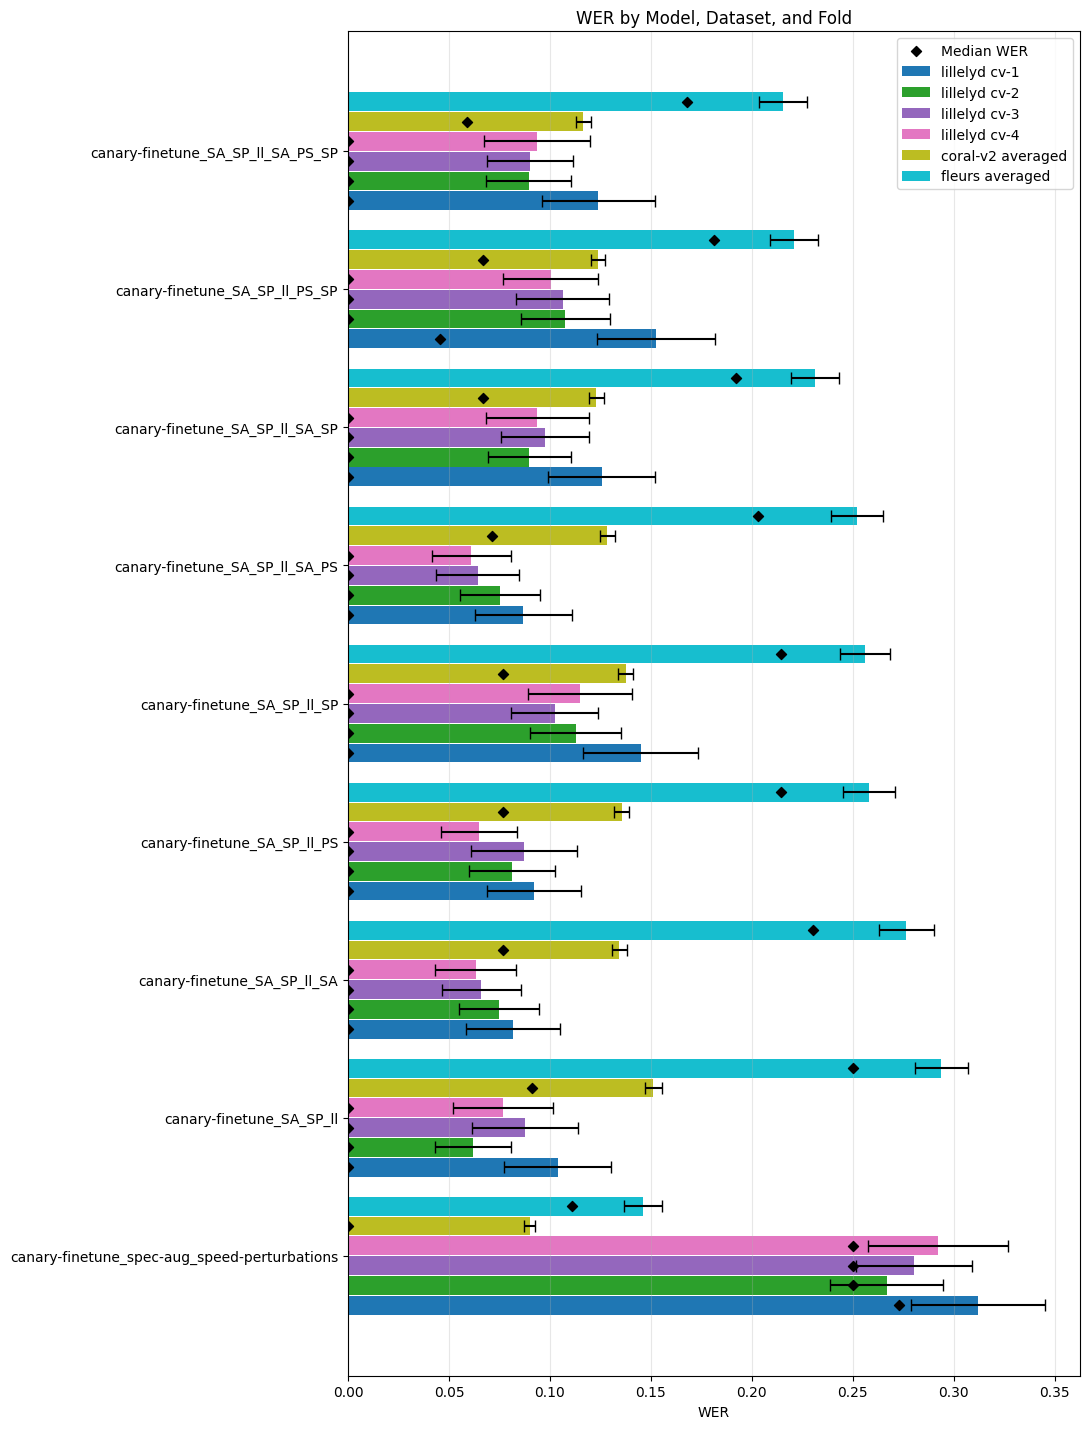

In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

MODELS = [
    "canary-finetune_spec-aug_speed-perturbations",
    "canary-finetune_SA_SP_ll",
    "canary-finetune_SA_SP_ll_SA",
    "canary-finetune_SA_SP_ll_PS",
    "canary-finetune_SA_SP_ll_SP",
    "canary-finetune_SA_SP_ll_SA_PS",
    "canary-finetune_SA_SP_ll_SA_SP",
    "canary-finetune_SA_SP_ll_PS_SP",
    "canary-finetune_SA_SP_ll_SA_PS_SP"
]

# load df from parquet
df = pd.read_parquet("../reports/metrics/lillelyd_finetune_combined_detailed_results_with_folds.parquet")



def mean_ci95(x: pd.Series):
    x = x.dropna().to_numpy()
    n = len(x)
    if n == 0:
        return np.nan, np.nan
    m = float(np.mean(x))
    if n == 1:
        return m, 0.0
    se = float(np.std(x, ddof=1) / np.sqrt(n))
    return m, 1.96 * se

def plot_models_all_datasets_by_fold(
    df: pd.DataFrame,
    title: str | None = None,
    savepath: str | None = None,
):
    """
    Required df columns:
      dataset_name: str    (values include 'lillelyd', 'coral-v2', 'fleurs')
      model: str
      cv_fold: str         (for lillelyd: cv-1..cv-4, for coral-v2/fleurs: averaged)
      WER: float
    """

    SERIES_LABELS = [
        "lillelyd cv-1",
        "lillelyd cv-2",
        "lillelyd cv-3",
        "lillelyd cv-4",
        "coral-v2 averaged",
        "fleurs averaged",
    ]

    COLORS = [
        "#1f77b4",  # blue
        "#2ca02c",  # green
        "#9467bd",  # purple
        "#e377c2",  # pink
        "#bcbd22",  # olive
        "#17becf",  # cyan
        "#000000",  # black
    ]

    color_map = dict(zip(SERIES_LABELS, COLORS))

    required = {"dataset_name", "model", "cv_fold", "WER"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"df is missing required columns: {sorted(missing)}")

    d = df.copy()

    # Define the exact series you want to show, in order
    series = [
        ("lillelyd", "cv-1", "lillelyd cv-1"),
        ("lillelyd", "cv-2", "lillelyd cv-2"),
        ("lillelyd", "cv-3", "lillelyd cv-3"),
        ("lillelyd", "cv-4", "lillelyd cv-4"),
        ("coral-v2", "averaged", "coral-v2 averaged"),
        ("fleurs", "averaged", "fleurs averaged"),
    ]

    # Filter to only those combinations
    keep = set((ds, fold) for ds, fold, _ in series)
    d = d[d["model"].isin(MODELS)].copy()
    d = d[d.apply(lambda r: (r["dataset_name"], r["cv_fold"]) in keep, axis=1)].copy()

    # Aggregate per (model, dataset_name, cv_fold)
    rows = []
    for (m, ds, f), g in d.groupby(["model", "dataset_name", "cv_fold"]):
        mean, ci95 = mean_ci95(g["WER"])
        median = float(np.median(g["WER"].dropna())) if len(g["WER"].dropna()) else np.nan
        rows.append({
            "model": m,
            "dataset_name": ds,
            "cv_fold": f,
            "mean": mean,
            "ci95": ci95,
            "median": median,
            "n": int(g["WER"].dropna().shape[0]),
        })

    agg = pd.DataFrame(rows)
    if len(agg) == 0:
        raise ValueError("No rows left after filtering. Check dataset_name and cv_fold values in df.")

    # Enforce model order
    agg["model"] = pd.Categorical(agg["model"], categories=MODELS, ordered=True)

    # Create a series key to enforce plotting order
    label_map = {(ds, f): lab for ds, f, lab in series}
    agg["series_label"] = agg.apply(lambda r: label_map[(r["dataset_name"], r["cv_fold"])], axis=1)
    series_labels = [lab for _, _, lab in series]
    agg["series_label"] = pd.Categorical(agg["series_label"], categories=series_labels, ordered=True)

    agg = agg.sort_values(["model", "series_label"])

    # Horizontal grouped bars
    y = np.arange(len(MODELS))
    group_height = 0.86
    k = len(series_labels)
    bar_h = group_height / k
    offsets = (np.arange(k) - (k - 1) / 2) * bar_h

    fig_w = 11
    fig_h = max(11.7, 1.6 * len(MODELS))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))


    for i, lab in enumerate(series_labels):
        sub = agg[agg["series_label"] == lab].set_index("model").reindex(MODELS)

        means = sub["mean"].to_numpy()
        errs = sub["ci95"].to_numpy()
        medians = sub["median"].to_numpy()

        ypos = y + offsets[i]

        ax.barh(
            ypos,
            means,
            height=bar_h * 0.95,
            xerr=errs,
            capsize=4,
            label=lab,
            color=color_map[lab],
        )

        ax.scatter(
            medians,
            ypos,
            marker="D",
            s=26,
            zorder=3,
            label="Median WER" if i == 0 else None,
            color="black",
        )

    ax.set_yticks(y)
    ax.set_yticklabels(MODELS)
    ax.set_xlabel("WER")
    ax.set_title(title if title else "WER by Model, Dataset, and Fold")
    ax.grid(True, axis="x", alpha=0.3)
    ax.legend()

    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    return fig, ax, agg

# Usage:
fig, ax, agg = plot_models_all_datasets_by_fold(df)
plt.show()


In [204]:
df = load_parquet(
        Path("../reports/metrics/lillelyd_finetune_stitched_detailed_results.parquet")
    )

In [205]:
# filter to coral
df_filtered_coral = df[df["dataset_name"].str.lower() == "coral-v2"].copy()

In [208]:
df_filtered_coral.head()

,id,prediction,label,clip_length,CER,WER,model,dataset_name,dataset_subset,dataset_split,...,location,location_roomdim,noise_level,noise_type,source_url,dialect,country_birth,validated,asr_prediction,asr_validation_model
19800,rec_0000ada48606067c1d22331fa67b3c24,befolkningen i dag er næsten udelukkende græks...,befolkningen i dag er næsten udelukkende græsk...,7.14,0.011765,0.083333,canary-finetune_SA_SP_ll,coral-v2,read_aloud,test,...,"Nygade 23A, 6200 Aabenraa","350,950,600",38,human,https://da.wikipedia.org/wiki/Epirus%20%28peri...,sønderjysk,DK,0,befolkningen i dag er næsten udelukkende græsk...,alexandrainst/coral-asr-bootstrap
19801,rec_0000ada48606067c1d22331fa67b3c24,befolkningen i dag er næsten udelukkende græks...,befolkningen i dag er næsten udelukkende græsk...,7.14,0.011765,0.083333,canary-finetune_SA_SP_ll_PS,coral-v2,read_aloud,test,...,"Nygade 23A, 6200 Aabenraa","350,950,600",38,human,https://da.wikipedia.org/wiki/Epirus%20%28peri...,sønderjysk,DK,0,befolkningen i dag er næsten udelukkende græsk...,alexandrainst/coral-asr-bootstrap
19802,rec_0000ada48606067c1d22331fa67b3c24,befolkningen i dag er næsten udelukkende græks...,befolkningen i dag er næsten udelukkende græsk...,7.14,0.011765,0.083333,canary-finetune_SA_SP_ll_PS_SP,coral-v2,read_aloud,test,...,"Nygade 23A, 6200 Aabenraa","350,950,600",38,human,https://da.wikipedia.org/wiki/Epirus%20%28peri...,sønderjysk,DK,0,befolkningen i dag er næsten udelukkende græsk...,alexandrainst/coral-asr-bootstrap
19803,rec_0000ada48606067c1d22331fa67b3c24,befolkningen i dag er næsten udelukkende græks...,befolkningen i dag er næsten udelukkende græsk...,7.14,0.011765,0.083333,canary-finetune_SA_SP_ll_SA,coral-v2,read_aloud,test,...,"Nygade 23A, 6200 Aabenraa","350,950,600",38,human,https://da.wikipedia.org/wiki/Epirus%20%28peri...,sønderjysk,DK,0,befolkningen i dag er næsten udelukkende græsk...,alexandrainst/coral-asr-bootstrap
19804,rec_0000ada48606067c1d22331fa67b3c24,befolkningen i dag er næsten udelukkende græks...,befolkningen i dag er næsten udelukkende græsk...,7.14,0.011765,0.083333,canary-finetune_SA_SP_ll_SA_PS,coral-v2,read_aloud,test,...,"Nygade 23A, 6200 Aabenraa","350,950,600",38,human,https://da.wikipedia.org/wiki/Epirus%20%28peri...,sønderjysk,DK,0,befolkningen i dag er næsten udelukkende græsk...,alexandrainst/coral-asr-bootstrap
